In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.signal import welch

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.linear_model import LinearRegression

In [4]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 10

print("All libraries imported successfully.")

All libraries imported successfully.


In [5]:
CSV_FILE         = "20251023-0003_02.csv"  
OUTPUT_DIR       = "ida_output"              
RESAMPLE_RATE_HZ = 20_000 

# Anomaly thresholds
ZSCORE_THRESHOLD = 3.0    # |Z| > this → anomaly
IQR_MULTIPLIER   = 1.5    # Tukey multiplier
SVM_NU           = 0.05   # Expected outlier fraction (0–1)
SVM_KERNEL       = 'rbf'
SVM_GAMMA        = 'scale'

DATASET_NAME = os.path.splitext(os.path.basename(CSV_FILE))[0]
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Dataset  : {DATASET_NAME}")
print(f"Output   : {os.path.abspath(OUTPUT_DIR)}")

Dataset  : 20251023-0003_02
Output   : C:\Users\ajith\OneDrive\Desktop\ida_output


In [6]:
df_raw = pd.read_csv("C:/Users/ajith/OneDrive/Desktop/project/Re_ Meeting/20251023-0003_02.csv", header=0, skiprows=[1])
df_raw.columns = ['Time_s', 'Amplitude_mV']
df_raw = df_raw.dropna().reset_index(drop=True)
df_raw['Time_s']       = pd.to_numeric(df_raw['Time_s'],       errors='coerce')
df_raw['Amplitude_mV'] = pd.to_numeric(df_raw['Amplitude_mV'], errors='coerce')
df_raw = df_raw.dropna().reset_index(drop=True)

# ── Resample to uniform grid ──────────────────────────────────────────────────
t_start    = df_raw['Time_s'].iloc[0]
t_end      = df_raw['Time_s'].iloc[-1]
n_samples  = int((t_end - t_start) * RESAMPLE_RATE_HZ)
t_uniform  = np.linspace(t_start, t_end, n_samples)
amp_interp = np.interp(t_uniform, df_raw['Time_s'].values, df_raw['Amplitude_mV'].values)

df = pd.DataFrame({'Time_s': t_uniform, 'Amplitude_mV': amp_interp})

print(f"Original samples  : {len(df_raw):,}")
print(f"Resampled samples : {len(df):,}  @  {RESAMPLE_RATE_HZ:,} Hz")
print(f"Signal duration   : {t_end - t_start:.4f} s")
df.head()

Original samples  : 100,004
Resampled samples : 100,002  @  20,000 Hz
Signal duration   : 5.0001 s


,Time_s,Amplitude_mV
0,0.00000,-2.697836
1,0.00005,0.367722
2,0.00010,-0.946091
3,0.00015,-1.383673
4,0.00020,4.305567


In [7]:
amp = df['Amplitude_mV']

stats_dict = {
    'Count'             : len(amp),
    'Mean (mV)'         : amp.mean(),
    'Std Dev (mV)'      : amp.std(),
    'Min (mV)'          : amp.min(),
    'Max (mV)'          : amp.max(),
    'Median (mV)'       : amp.median(),
    'Q1 (mV)'           : amp.quantile(0.25),
    'Q3 (mV)'           : amp.quantile(0.75),
    'IQR (mV)'          : amp.quantile(0.75) - amp.quantile(0.25),
    'Skewness'          : amp.skew(),
    'Kurtosis'          : amp.kurtosis(),
    'RMS (mV)'          : float(np.sqrt(np.mean(amp ** 2))),
    'Peak-to-Peak (mV)' : float(amp.max() - amp.min()),
    'Crest Factor'      : float(amp.abs().max() / (np.sqrt(np.mean(amp ** 2)) + 1e-12)),
}

stats_df = pd.DataFrame(list(stats_dict.items()), columns=['Metric', 'Value'])
stats_df['Value'] = stats_df['Value'].apply(lambda x: f"{x:,.6f}" if isinstance(x, float) else f"{x:,}")
stats_df

,Metric,Value
0,Count,"100,002.000000"
1,Mean (mV),0.057025
2,Std Dev (mV),3.338909
3,Min (mV),-23.056499
4,Max (mV),23.574822
5,Median (mV),0.032674
6,Q1 (mV),-1.335415
7,Q3 (mV),1.444034
8,IQR (mV),2.779450
9,Skewness,0.017478


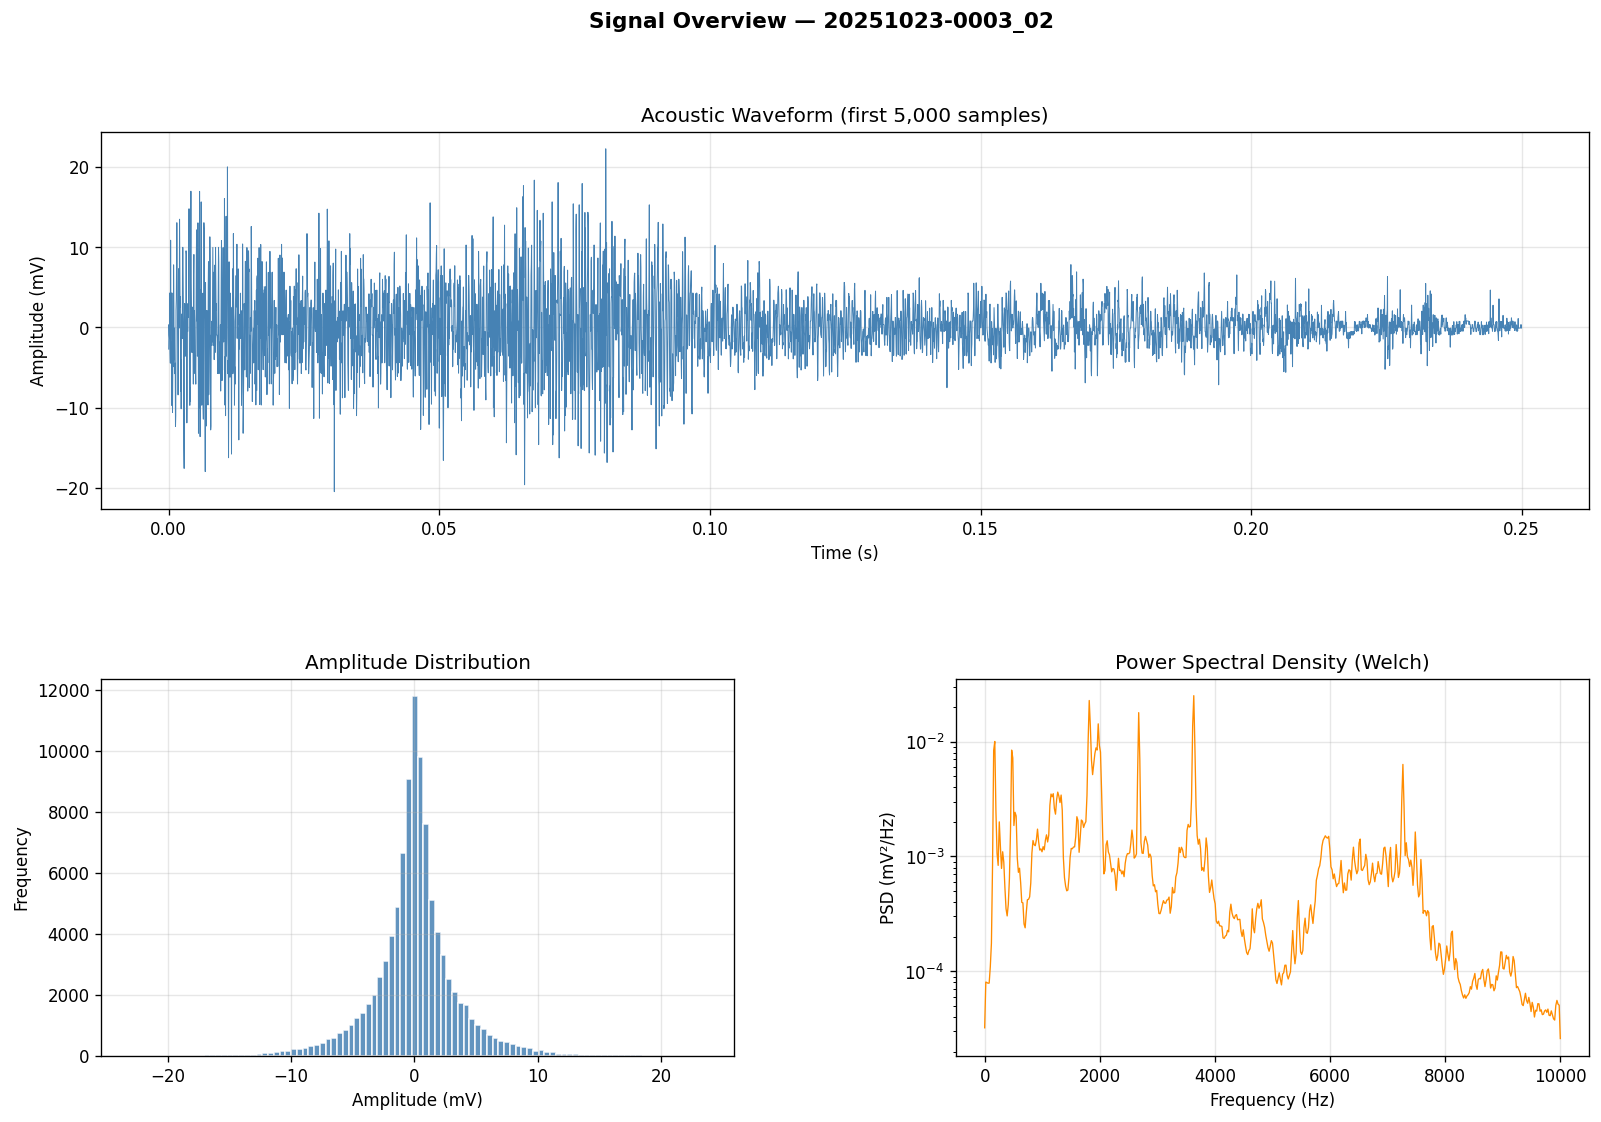

Plot saved.


In [8]:
amp_arr  = df['Amplitude_mV'].values
time_arr = df['Time_s'].values
n_plot   = min(5000, len(time_arr))

fig = plt.figure(figsize=(16, 10))
fig.suptitle(f"Signal Overview — {DATASET_NAME}", fontsize=13, fontweight='bold')
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# Waveform
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(time_arr[:n_plot], amp_arr[:n_plot], color='steelblue', linewidth=0.6)
ax1.set_title("Acoustic Waveform (first 5,000 samples)")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Amplitude (mV)")
ax1.grid(True, alpha=0.3)

# Histogram
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(amp_arr, bins=100, color='steelblue', edgecolor='white', alpha=0.85)
ax2.set_title("Amplitude Distribution")
ax2.set_xlabel("Amplitude (mV)")
ax2.set_ylabel("Frequency")
ax2.grid(True, alpha=0.3)

# Power Spectral Density
ax3 = fig.add_subplot(gs[1, 1])
freqs, psd = welch(amp_arr, fs=RESAMPLE_RATE_HZ, nperseg=1024)
ax3.semilogy(freqs, psd, color='darkorange', linewidth=0.8)
ax3.set_title("Power Spectral Density (Welch)")
ax3.set_xlabel("Frequency (Hz)")
ax3.set_ylabel("PSD (mV²/Hz)")
ax3.grid(True, alpha=0.3)

plt.savefig(f"{OUTPUT_DIR}/{DATASET_NAME}_1_signal_overview.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

Z-Score threshold  : ±3
Anomalies detected : 1,718  (1.72%)


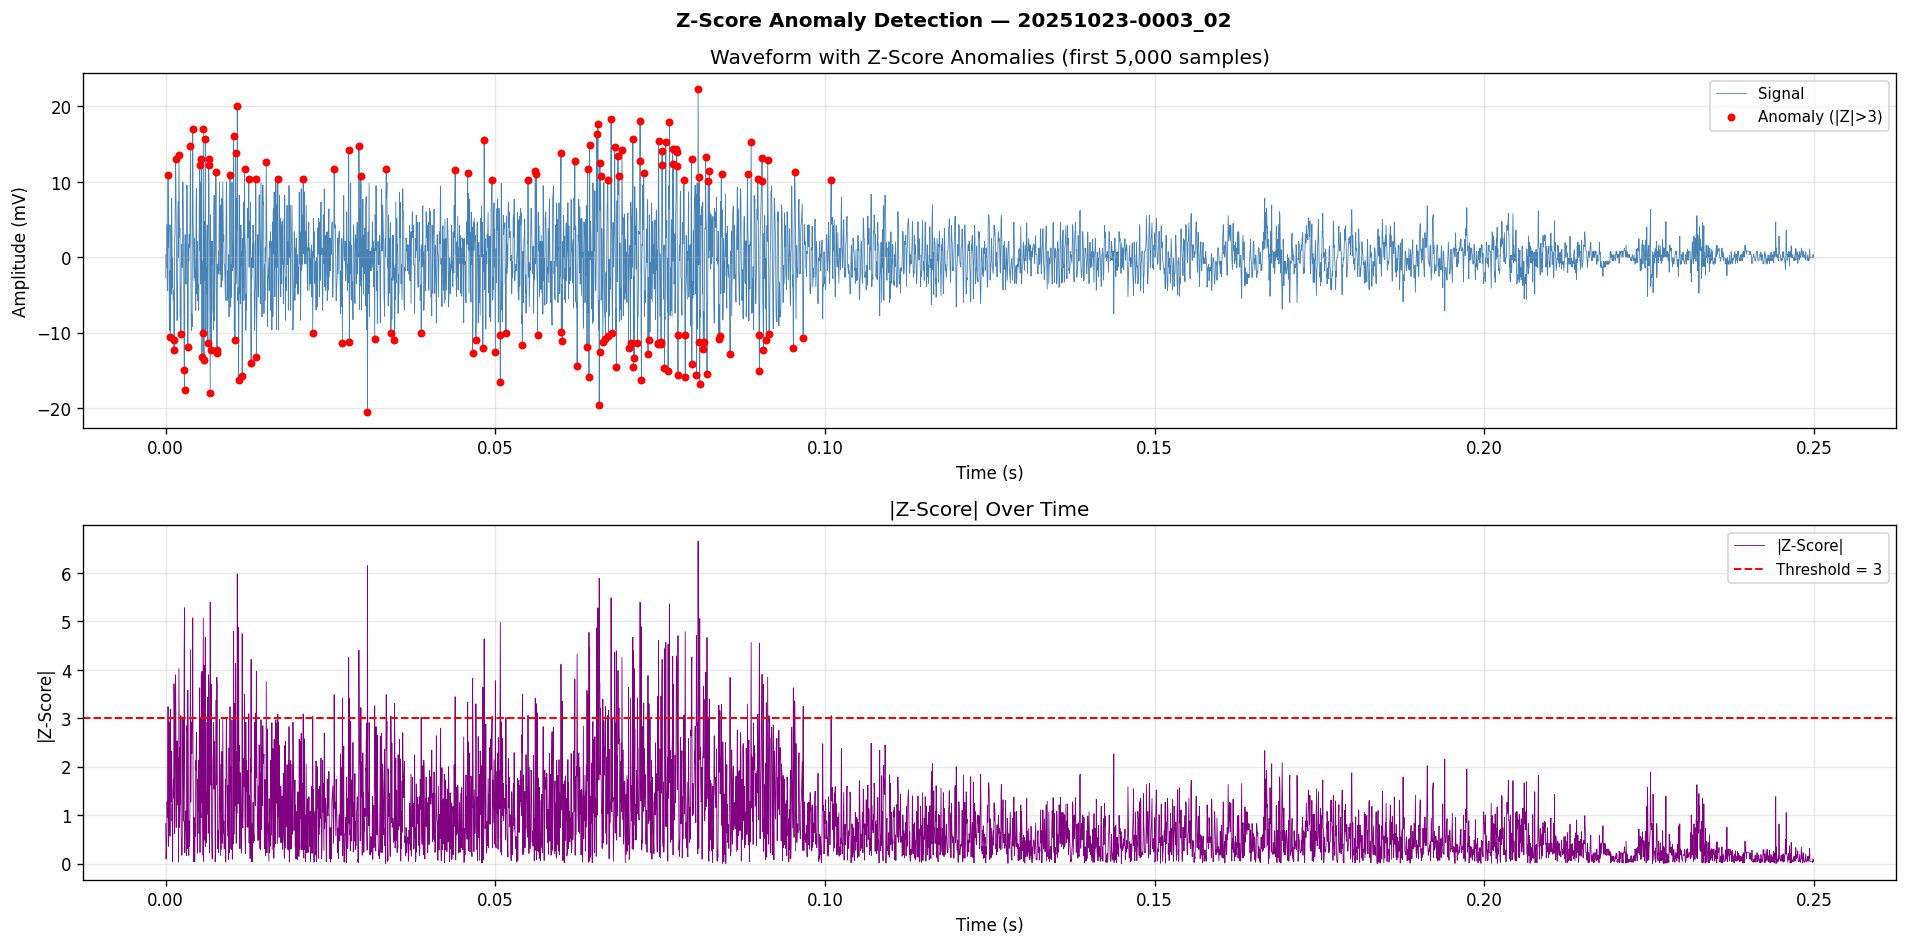

Plot saved.


In [9]:
# Z score
ZSCORE_THRESHOLD = 3
z_scores     = np.abs(stats.zscore(amp_arr))
z_anomaly    = z_scores > ZSCORE_THRESHOLD
z_count      = z_anomaly.sum()
z_pct        = 100 * z_count / len(amp_arr)

print(f"Z-Score threshold  : ±{ZSCORE_THRESHOLD}")
print(f"Anomalies detected : {z_count:,}  ({z_pct:.2f}%)")

fig, axes = plt.subplots(2, 1, figsize=(16, 8))
fig.suptitle(f"Z-Score Anomaly Detection — {DATASET_NAME}", fontsize=12, fontweight='bold')

anom_idx = np.where(z_anomaly[:n_plot])[0]
axes[0].plot(time_arr[:n_plot], amp_arr[:n_plot], color='steelblue', lw=0.5, label='Signal', zorder=1)
axes[0].scatter(time_arr[:n_plot][anom_idx], amp_arr[:n_plot][anom_idx],
                color='red', s=14, zorder=2, label=f'Anomaly (|Z|>{ZSCORE_THRESHOLD})')
axes[0].set_title("Waveform with Z-Score Anomalies (first 5,000 samples)")
axes[0].set_xlabel("Time (s)"); axes[0].set_ylabel("Amplitude (mV)")
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

axes[1].plot(time_arr[:n_plot], z_scores[:n_plot], color='purple', lw=0.5, label='|Z-Score|')
axes[1].axhline(ZSCORE_THRESHOLD, color='red', ls='--', lw=1.2, label=f'Threshold = {ZSCORE_THRESHOLD}')
axes[1].set_title("|Z-Score| Over Time")
axes[1].set_xlabel("Time (s)"); axes[1].set_ylabel("|Z-Score|")
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{DATASET_NAME}_2_zscore.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

Q1 = -1.3354 mV  |  Q3 = 1.4440 mV  |  IQR = 2.7794 mV
Lower fence : -5.5046 mV
Upper fence : 5.6132 mV
Anomalies   : 9,835  (9.83%)


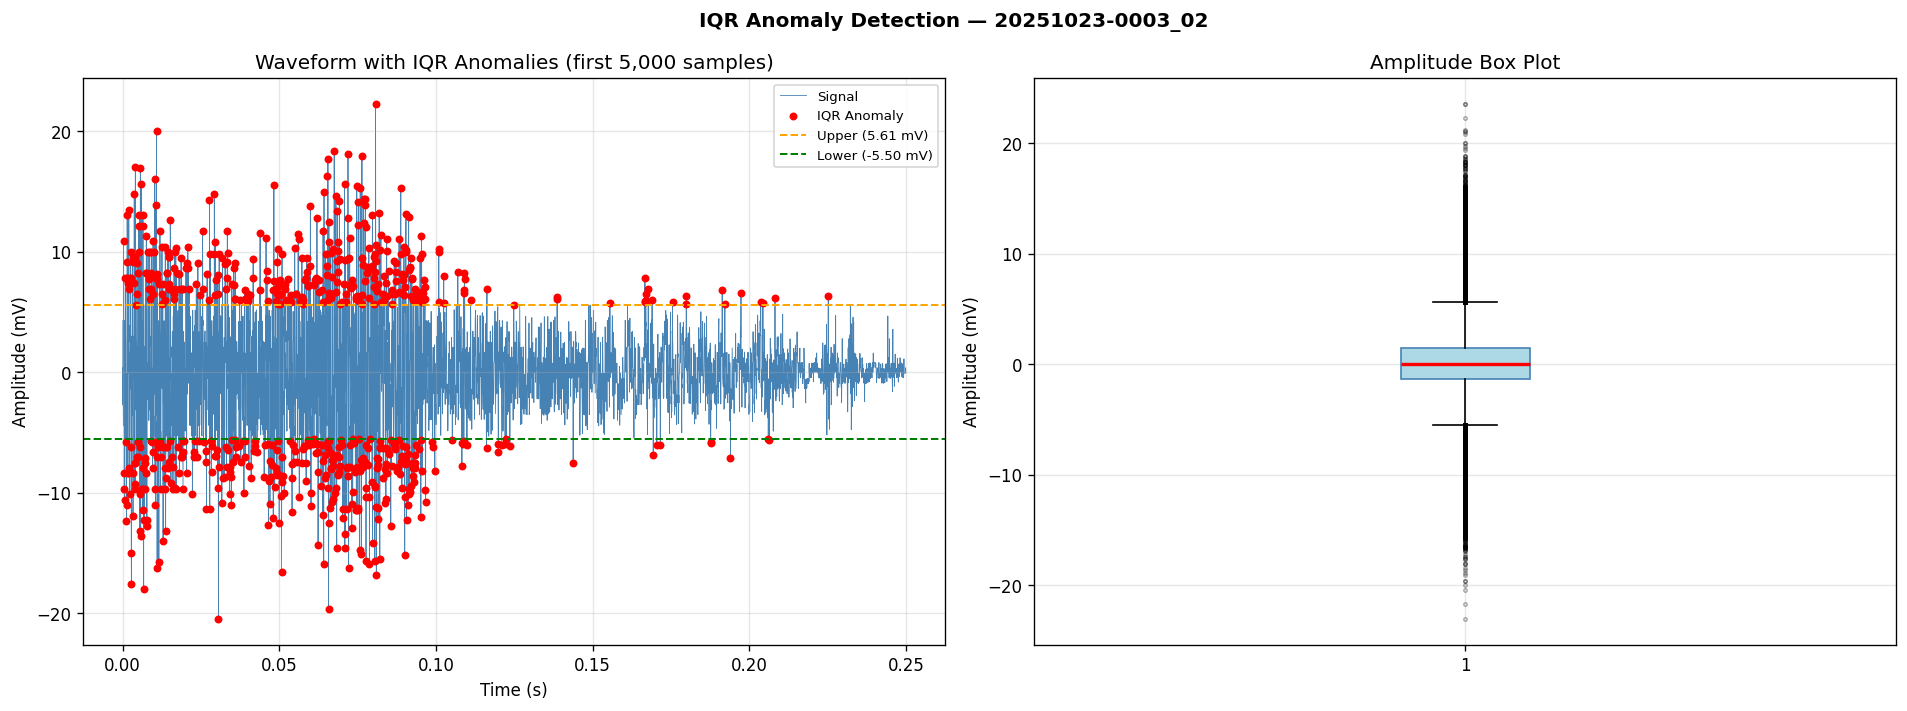

Plot saved.


In [10]:
#IQR 
Q1  = np.percentile(amp_arr, 25)
Q3  = np.percentile(amp_arr, 75)
IQR = Q3 - Q1
lower_fence = Q1 - IQR_MULTIPLIER * IQR
upper_fence = Q3 + IQR_MULTIPLIER * IQR

iqr_anomaly = (amp_arr < lower_fence) | (amp_arr > upper_fence)
iqr_count   = iqr_anomaly.sum()
iqr_pct     = 100 * iqr_count / len(amp_arr)

print(f"Q1 = {Q1:.4f} mV  |  Q3 = {Q3:.4f} mV  |  IQR = {IQR:.4f} mV")
print(f"Lower fence : {lower_fence:.4f} mV")
print(f"Upper fence : {upper_fence:.4f} mV")
print(f"Anomalies   : {iqr_count:,}  ({iqr_pct:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"IQR Anomaly Detection — {DATASET_NAME}", fontsize=12, fontweight='bold')

anom_idx = np.where(iqr_anomaly[:n_plot])[0]
axes[0].plot(time_arr[:n_plot], amp_arr[:n_plot], color='steelblue', lw=0.5, label='Signal', zorder=1)
axes[0].scatter(time_arr[:n_plot][anom_idx], amp_arr[:n_plot][anom_idx],
                color='red', s=14, zorder=2, label='IQR Anomaly')
axes[0].axhline(upper_fence, color='orange', ls='--', lw=1.2, label=f'Upper ({upper_fence:.2f} mV)')
axes[0].axhline(lower_fence, color='green',  ls='--', lw=1.2, label=f'Lower ({lower_fence:.2f} mV)')
axes[0].set_title("Waveform with IQR Anomalies (first 5,000 samples)")
axes[0].set_xlabel("Time (s)"); axes[0].set_ylabel("Amplitude (mV)")
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

axes[1].boxplot(amp_arr, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='steelblue'),
                medianprops=dict(color='red', linewidth=2),
                flierprops=dict(marker='o', color='red', markersize=2, alpha=0.3))
axes[1].set_title("Amplitude Box Plot")
axes[1].set_ylabel("Amplitude (mV)"); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{DATASET_NAME}_3_iqr.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

Slope      : -0.000233 mV/s
Intercept  : 0.057609 mV
Residual σ : 3.338892 mV
Anomalies  : 1,718  (1.72%)


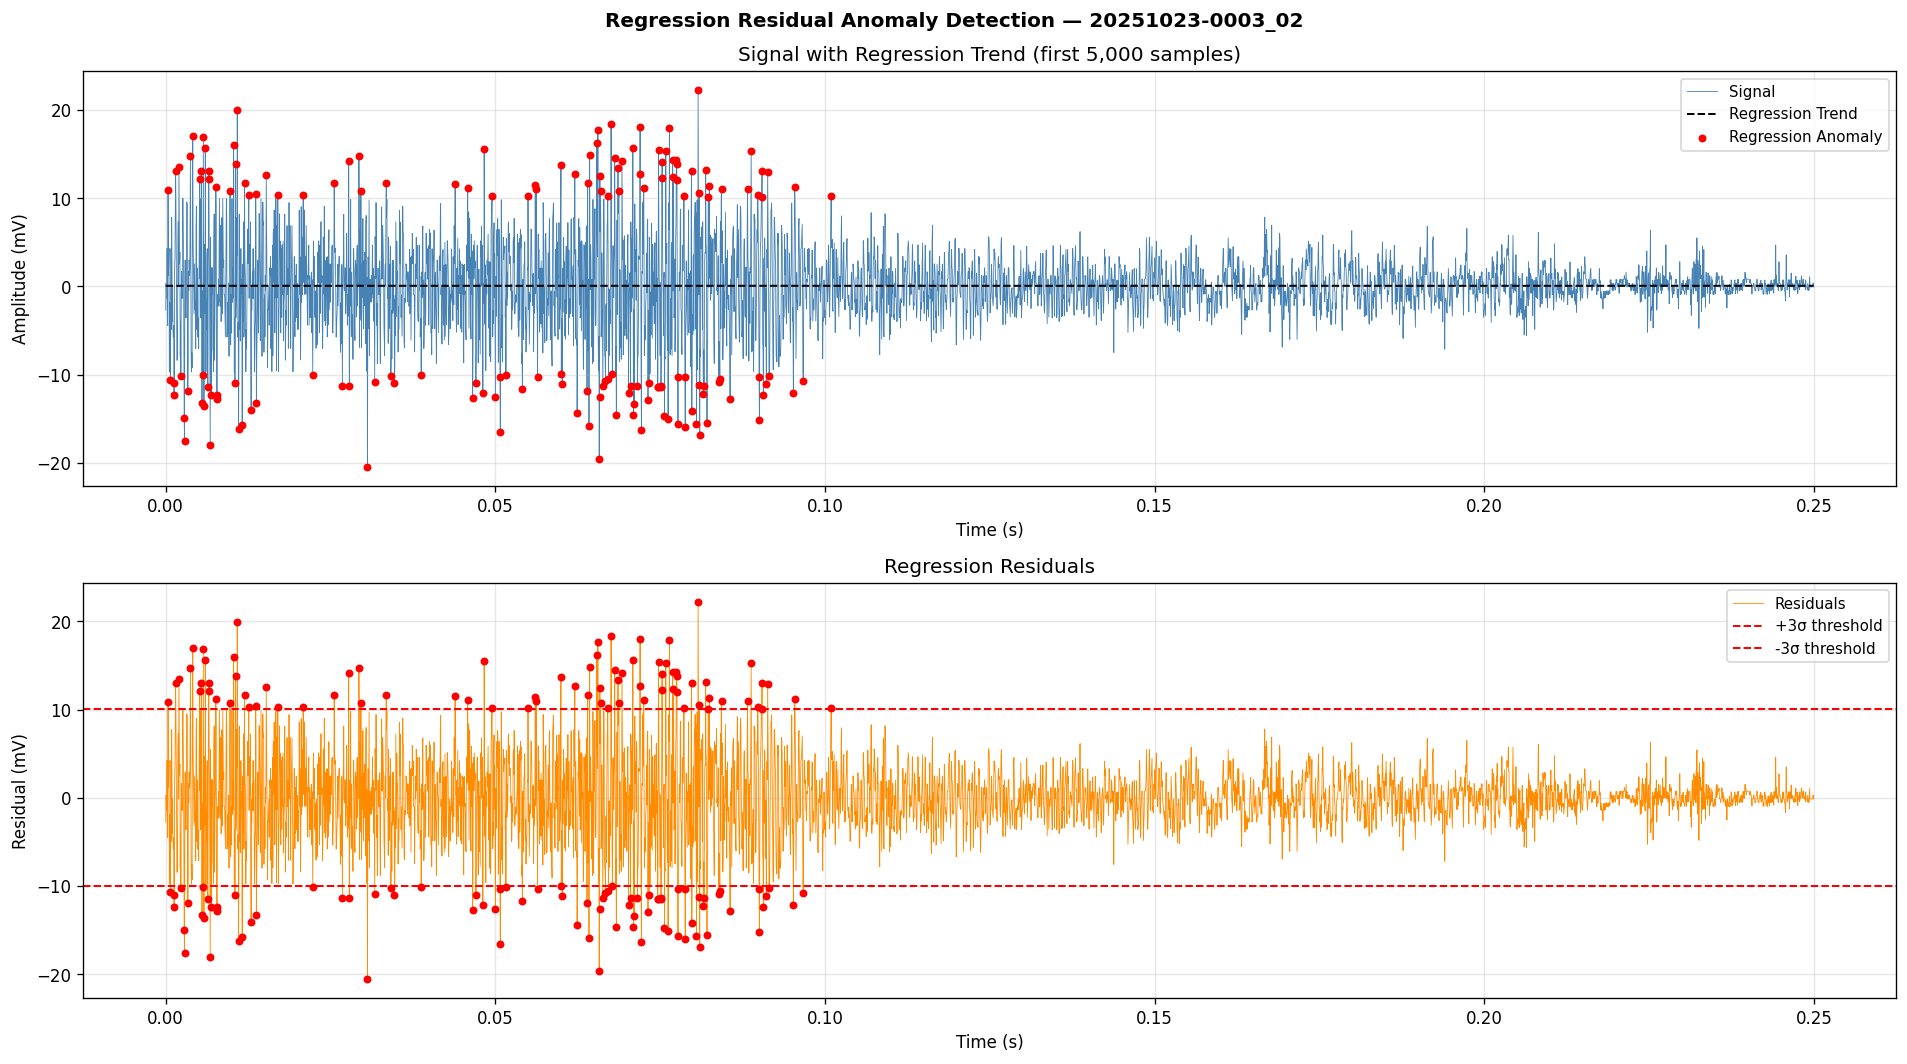

Plot saved.


In [11]:
#regression
time_2d   = df['Time_s'].values.reshape(-1, 1)
reg_model = LinearRegression().fit(time_2d, amp_arr)
predicted = reg_model.predict(time_2d)
residuals = amp_arr - predicted
res_z     = np.abs(stats.zscore(residuals))
reg_anomaly = res_z > ZSCORE_THRESHOLD
reg_count   = reg_anomaly.sum()
reg_pct     = 100 * reg_count / len(amp_arr)

print(f"Slope      : {reg_model.coef_[0]:.6f} mV/s")
print(f"Intercept  : {reg_model.intercept_:.6f} mV")
print(f"Residual σ : {residuals.std():.6f} mV")
print(f"Anomalies  : {reg_count:,}  ({reg_pct:.2f}%)")

fig, axes = plt.subplots(2, 1, figsize=(16, 9))
fig.suptitle(f"Regression Residual Anomaly Detection — {DATASET_NAME}", fontsize=12, fontweight='bold')

anom_idx = np.where(reg_anomaly[:n_plot])[0]
axes[0].plot(time_arr[:n_plot], amp_arr[:n_plot], color='steelblue', lw=0.5, label='Signal', zorder=1)
axes[0].plot(time_arr[:n_plot], predicted[:n_plot], color='black', lw=1.2, ls='--',
             label='Regression Trend', zorder=2)
axes[0].scatter(time_arr[:n_plot][anom_idx], amp_arr[:n_plot][anom_idx],
                color='red', s=14, zorder=3, label='Regression Anomaly')
axes[0].set_title("Signal with Regression Trend (first 5,000 samples)")
axes[0].set_xlabel("Time (s)"); axes[0].set_ylabel("Amplitude (mV)")
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

thr_line = ZSCORE_THRESHOLD * residuals.std()
axes[1].plot(time_arr[:n_plot], residuals[:n_plot], color='darkorange', lw=0.5, label='Residuals')
axes[1].axhline( thr_line, color='red', ls='--', lw=1.2, label=f'+{ZSCORE_THRESHOLD}σ threshold')
axes[1].axhline(-thr_line, color='red', ls='--', lw=1.2, label=f'-{ZSCORE_THRESHOLD}σ threshold')
axes[1].scatter(time_arr[:n_plot][anom_idx], residuals[:n_plot][anom_idx],
                color='red', s=14, zorder=3)
axes[1].set_title("Regression Residuals")
axes[1].set_xlabel("Time (s)"); axes[1].set_ylabel("Residual (mV)")
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{DATASET_NAME}_4_regression.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

Total samples      : 100,002
Fitted on          : 50,000 samples
Anomalies detected : 4,911  (4.91%)


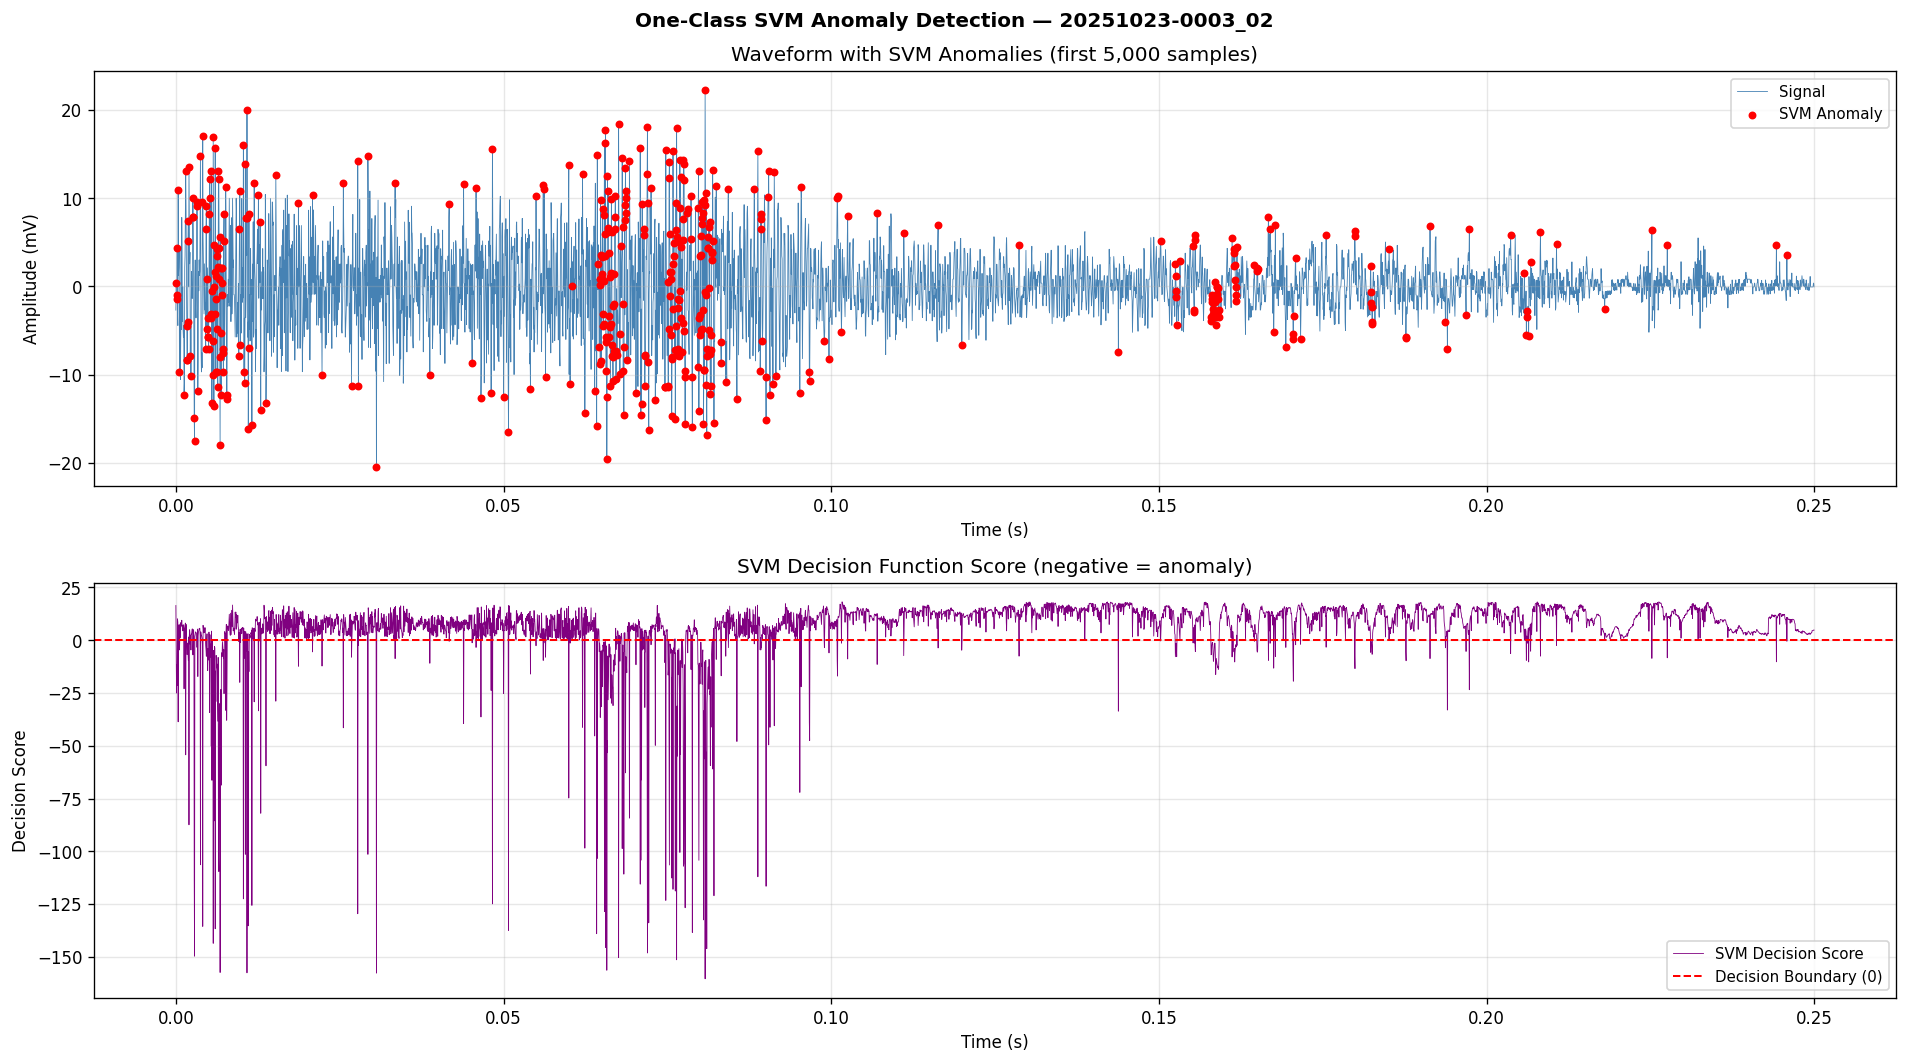

Plot saved.


In [14]:
#smv 
# Feature Engineering
window    = 50
roll_mean = pd.Series(amp_arr).rolling(window, center=True, min_periods=1).mean().values
roll_std  = pd.Series(amp_arr).rolling(window, center=True, min_periods=1).std().fillna(0).values
energy    = amp_arr ** 2

X        = np.column_stack([amp_arr, roll_mean, roll_std, energy])
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit One-Class SVM (subsample if large) 
max_fit  = 50_000
n_total  = len(X_scaled)
if n_total > max_fit:
    idx_fit = np.sort(np.random.choice(n_total, max_fit, replace=False))
    X_fit   = X_scaled[idx_fit]
else:
    X_fit   = X_scaled

clf = OneClassSVM(nu=SVM_NU, kernel=SVM_KERNEL, gamma=SVM_GAMMA)
clf.fit(X_fit)

predictions  = clf.predict(X_scaled)
svm_anomaly  = predictions == -1
svm_count    = svm_anomaly.sum()
svm_pct      = 100 * svm_count / n_total
dec_scores   = clf.decision_function(X_scaled)

print(f"Total samples      : {n_total:,}")
print(f"Fitted on          : {len(X_fit):,} samples")
print(f"Anomalies detected : {svm_count:,}  ({svm_pct:.2f}%)")

fig, axes = plt.subplots(2, 1, figsize=(16, 9))
fig.suptitle(f"One-Class SVM Anomaly Detection — {DATASET_NAME}", fontsize=12, fontweight='bold')

anom_idx = np.where(svm_anomaly[:n_plot])[0]
axes[0].plot(time_arr[:n_plot], amp_arr[:n_plot], color='steelblue', lw=0.5, label='Signal', zorder=1)
axes[0].scatter(time_arr[:n_plot][anom_idx], amp_arr[:n_plot][anom_idx],
                color='red', s=14, zorder=2, label='SVM Anomaly')
axes[0].set_title("Waveform with SVM Anomalies (first 5,000 samples)")
axes[0].set_xlabel("Time (s)"); axes[0].set_ylabel("Amplitude (mV)")
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

axes[1].plot(time_arr[:n_plot], dec_scores[:n_plot], color='purple', lw=0.5, label='SVM Decision Score')
axes[1].axhline(0, color='red', ls='--', lw=1.2, label='Decision Boundary (0)')
axes[1].set_title("SVM Decision Function Score (negative = anomaly)")
axes[1].set_xlabel("Time (s)"); axes[1].set_ylabel("Decision Score")
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{DATASET_NAME}_5_svm.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

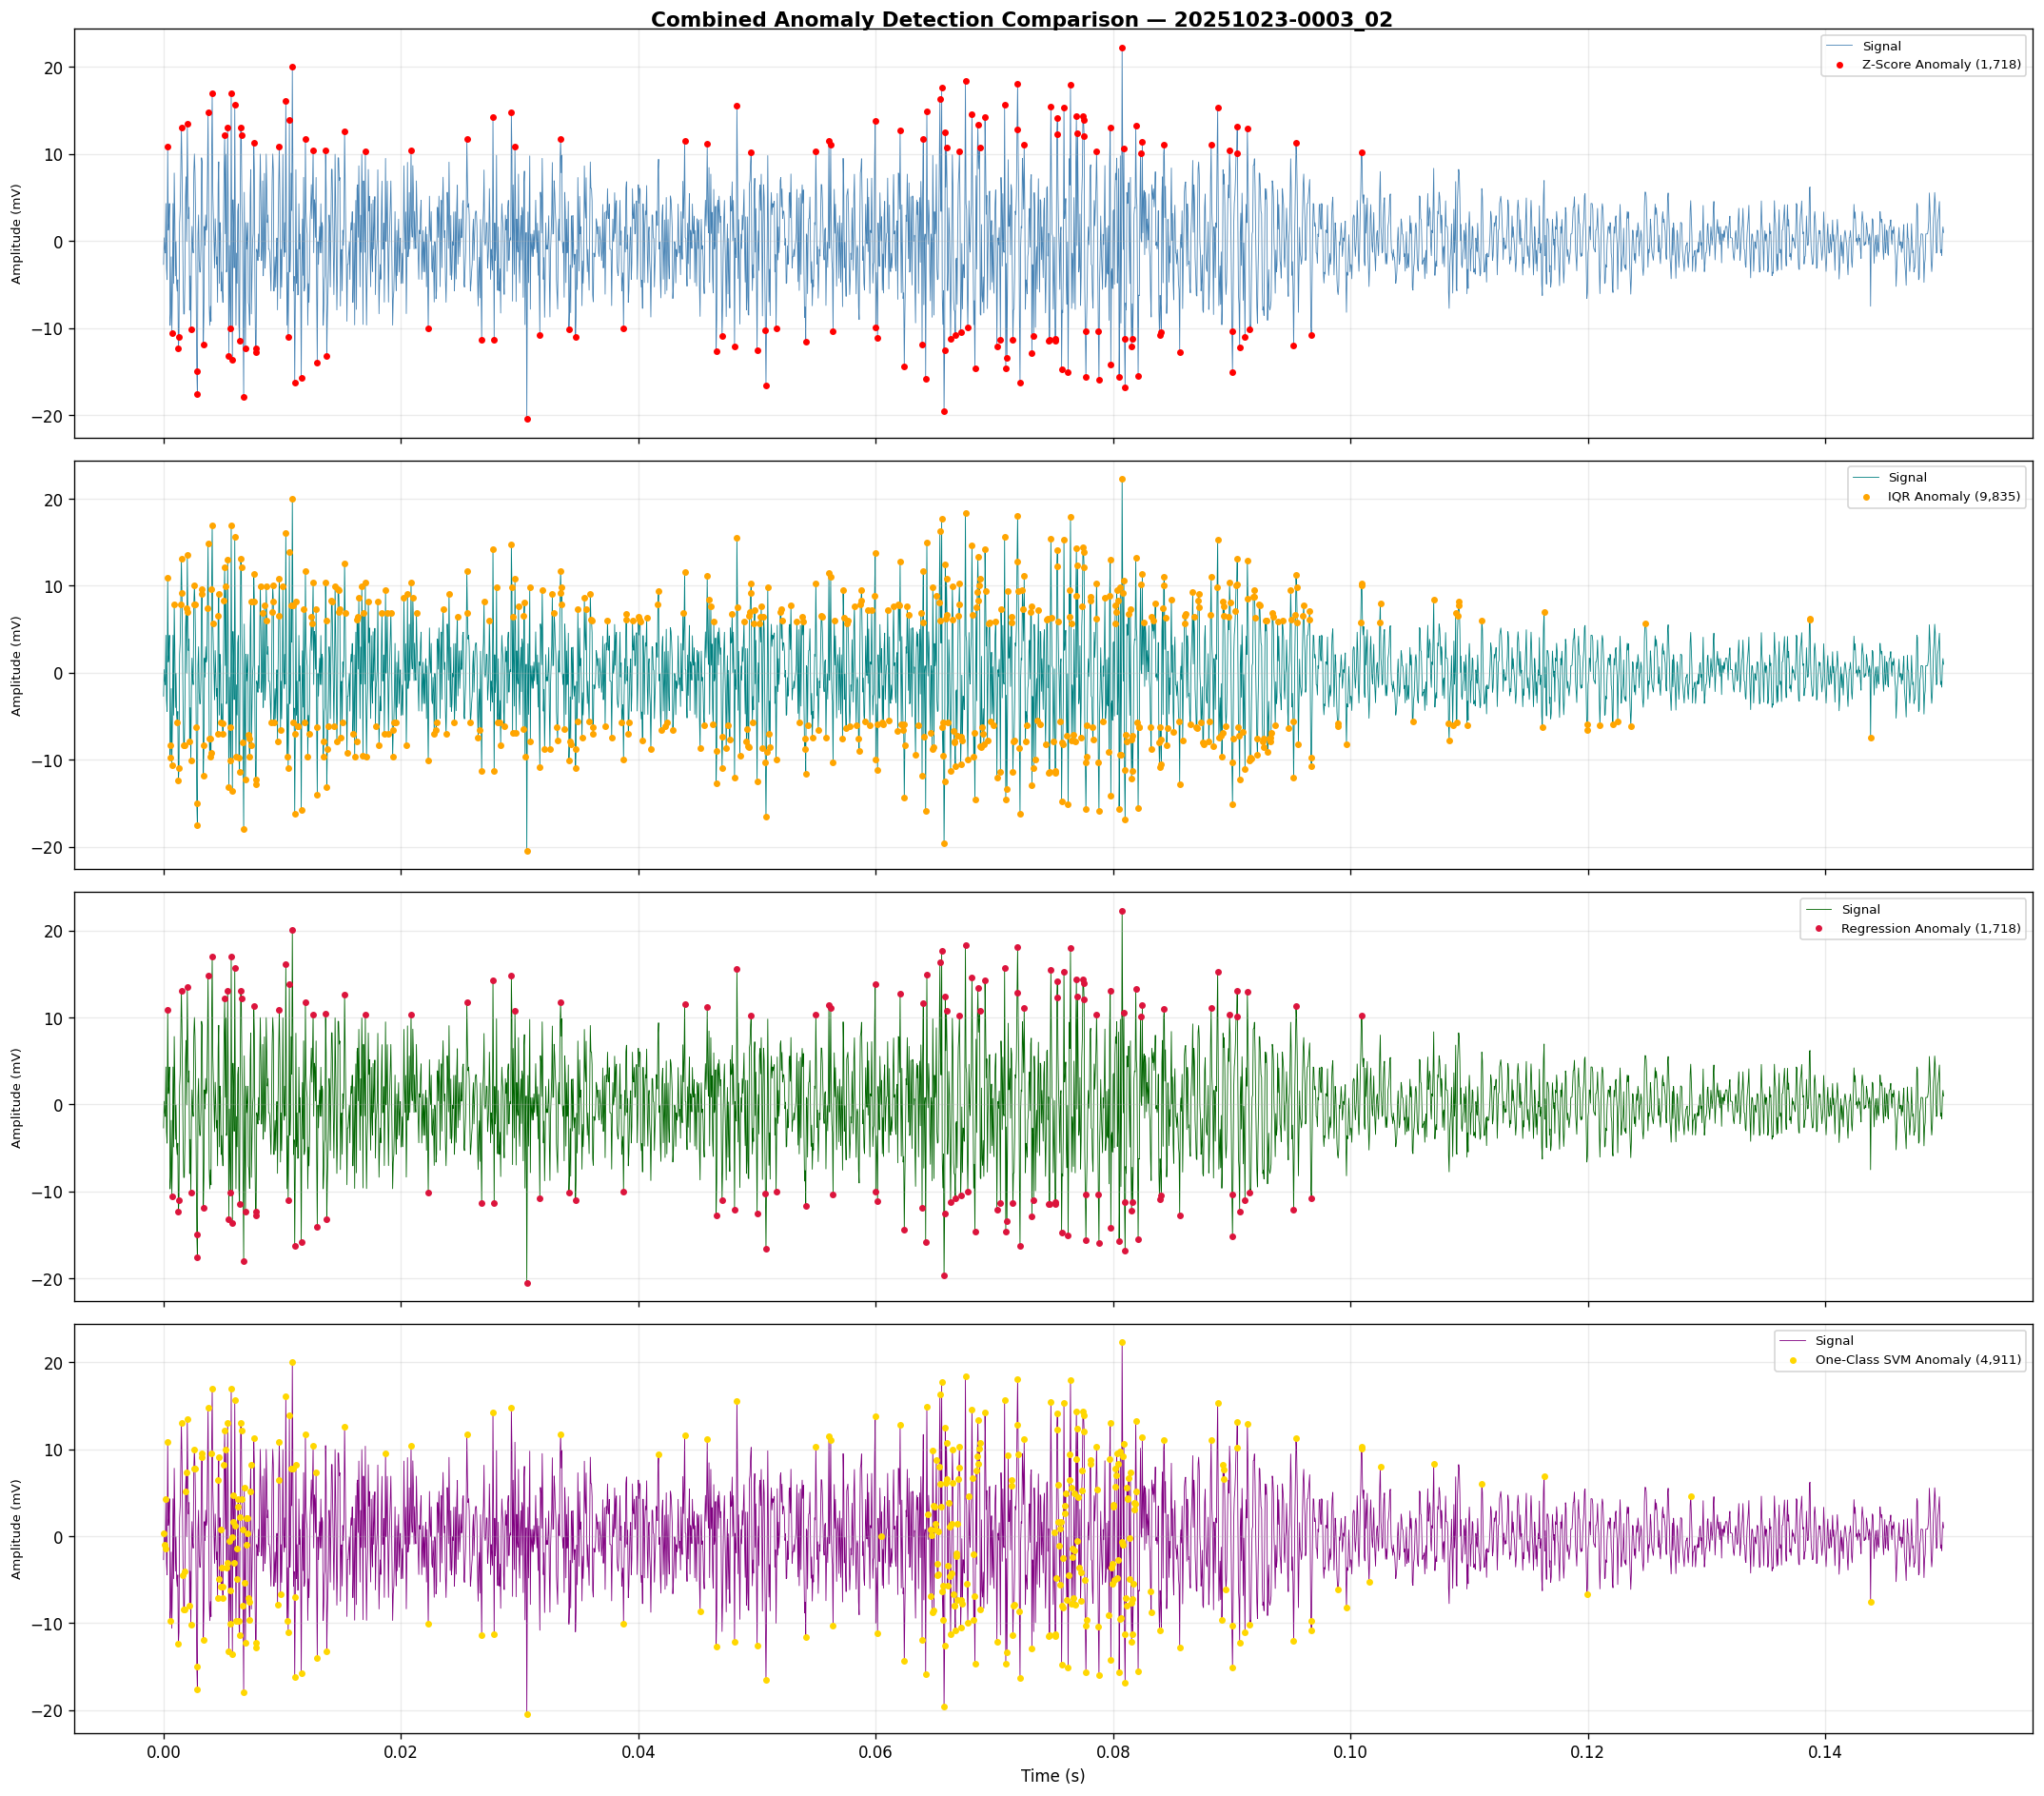

Plot saved.


In [15]:
##Combined Anomaly Detection Comparison
n_cmp = min(3000, len(amp_arr))
fig, axes = plt.subplots(4, 1, figsize=(18, 16), sharex=True)
fig.suptitle(f"Combined Anomaly Detection Comparison — {DATASET_NAME}",
             fontsize=13, fontweight='bold')

method_data = [
    (z_anomaly,   axes[0], 'Z-Score',        'steelblue', 'red',    z_count),
    (iqr_anomaly, axes[1], 'IQR',             'teal',      'orange', iqr_count),
    (reg_anomaly, axes[2], 'Regression',      'darkgreen', 'crimson',reg_count),
    (svm_anomaly, axes[3], 'One-Class SVM',   'purple',    'gold',   svm_count),
]

for mask, ax, label, sig_col, anom_col, cnt in method_data:
    ai = np.where(mask[:n_cmp])[0]
    ax.plot(time_arr[:n_cmp], amp_arr[:n_cmp], color=sig_col, lw=0.5, label='Signal', zorder=1)
    ax.scatter(time_arr[:n_cmp][ai], amp_arr[:n_cmp][ai],
               color=anom_col, s=10, zorder=2, label=f'{label} Anomaly ({cnt:,})')
    ax.set_ylabel("Amplitude (mV)", fontsize=8)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/{DATASET_NAME}_6_combined_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")